In [1]:
import numpy as np
import tifffile

# functions copied from mbo_utiliteis
def _phase_corr_2d(frame, border=4, max_offset=10, use_fft=True):
    """Estimate horizontal shift between odd and even rows of a 2D image via
    1D rFFT phase correlation along x. Parabolic peak refinement gives ~0.05 px."""
    w = frame.shape[1]
    even = frame[::2]
    odd = frame[1::2]
    m = min(even.shape[0], odd.shape[0])
    even = even[border:m - border, border:w - border].astype(np.float32, copy=False)
    odd = odd[border:m - border, border:w - border].astype(np.float32, copy=False)

    Lx = even.shape[-1]
    fe = np.fft.rfft(even, axis=-1); fe /= np.abs(fe) + 1e-5
    fo = np.fft.rfft(odd, axis=-1); fo /= np.abs(fo) + 1e-5
    cc = np.fft.fftshift(np.fft.irfft(fe * np.conj(fo), n=Lx, axis=-1).mean(axis=0))

    win = max_offset or Lx // 2
    lo, hi = Lx // 2 - win, Lx // 2 + win + 1
    int_shift = int(np.argmax(cc[lo:hi]) - win)
    if not use_fft:
        return float(int_shift)

    idx = Lx // 2 + int_shift
    if 0 < idx < Lx - 1:
        y0, y1, y2 = cc[idx - 1], cc[idx], cc[idx + 1]
        denom = y0 - 2 * y1 + y2
        sub = 0.5 * (y0 - y2) / denom if abs(denom) > 1e-12 else 0.0
        return float(int_shift) + float(np.clip(sub, -0.5, 0.5))
    return float(int_shift)


def _apply_offset(img, offset, use_fft=True):
    """Shift every odd row of `img` by `offset` px along x, in place. Works on a
    2D frame or a 3D (T, Y, X) stack. Subpixel via rFFT, else integer np.roll."""
    rows = img[..., 1::2, :]
    if use_fft and offset != round(offset):
        n = rows.shape[-1]
        f = np.fft.rfft(rows.astype(np.float32, copy=False), axis=-1)
        k = np.fft.rfftfreq(n)
        phase = np.exp(-2j * np.pi * k * offset).astype(np.complex64)
        img[..., 1::2, :] = np.fft.irfft(f * phase, n=n, axis=-1).astype(img.dtype, copy=False)
    else:
        rows[:] = np.roll(rows, shift=int(round(offset)), axis=-1)
    return img

In [7]:
path = r"E:\datasets\pollen\2026-03-31_thorlabs-obj-testing\Pollen_4p1x_1um-Step_Thorlabs28x\Pollen_4p1x_1um-Step_Thorlabs28x_00001.tif"
movie = tifffile.imread(path)
movie.shape
print(f"\nArray shape: \n {movie.shape}, TXY")

<tifffile.TiffFile 'Pollen_4p1x_1um-…bs28x_00001.tif'> <asarray> failed to reshape (1694, 224, 224) to (100, 14, 224, 224), raised ValueError('cannot reshape array of size 84998144 into shape (100,14,224,224)')



Array shape: 
 (1694, 224, 224), TXY


In [8]:
window = 200 # frames
exclude_border = 3 # pixels to exclude from edges of FOV
max_offset = 5 # prevent low signal fft from producing large, innacurate offsets
movie = np.asarray(movie)
corrected = np.empty_like(movie)
offsets = []
for start in range(0, movie.shape[0], window):
    print(f"Running window frames {start}:{start + window}")
    block = movie[start:start + window]
    offset = _phase_corr_2d(block.mean(axis=0), 0, max_offset, use_fft=True)
    corrected[start:start + window] = _apply_offset(block.copy(), offset, use_fft=True)
    offsets.append(offset)
    print(f"frames {start:>6}-{start + len(block):<6} offset={offset:+.3f}px")

Running window frames 0:200
frames      0-200    offset=+1.174px
Running window frames 200:400
frames    200-400    offset=+1.064px
Running window frames 400:600
frames    400-600    offset=+0.952px
Running window frames 600:800
frames    600-800    offset=+0.468px
Running window frames 800:1000
frames    800-1000   offset=-0.125px
Running window frames 1000:1200
frames   1000-1200   offset=-0.788px
Running window frames 1200:1400
frames   1200-1400   offset=-0.222px
Running window frames 1400:1600
frames   1400-1600   offset=+0.520px
Running window frames 1600:1800
frames   1600-1694   offset=+0.850px


In [10]:
np.mean(offsets)

np.float64(0.43260180743204224)

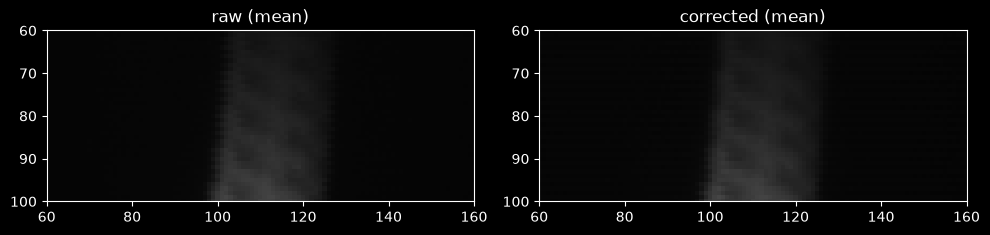

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(movie.mean(0), cmap="gray"); ax[0].set_title("raw (mean)")
ax[1].imshow(corrected.mean(0), cmap="gray"); ax[1].set_title("corrected (mean)")
for a in ax:
    a.set_xlim(60, 160); a.set_ylim(100, 60)  # zoom in to see the row tearing
plt.tight_layout()